### Supp 3. Previous trial reward's correct rate and change of mind

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats

import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.decodeHelpers import runSessionNames

from spyglass.shijiegu.changeOfMind_triggered import (find_triggered_animal,find_triggered_transition_animal,
    find_triggered_log_session, find_triggered_log_animal,labels,seq1,seq2,rev1,rev2,rev3)

[2025-10-11 21:23:30,977][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[21:23:37][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:23:37][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [5]:
from spyglass.shijiegu.changeOfMind_figures.supp3_correctness import find_the_last_trial_animal

In [4]:
seqs = {"Molly":seq2, "Eliot":seq2,"Klein":rev2,"Lewis1":rev2,"Julio":seq2}

### Pre + Post learning

In [7]:
animals = ["Molly","Eliot","Klein","Lewis1","Julio"]

data = {}

data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
output_folder = '/stelmo/shijie/change_of_mind_analysis/suppfigure3'
for animal in animals:
    file_path = f"{data_folder}/{animal}_bias_analysis.pickle"
    with open(file_path, 'rb') as file:
        data[animal] = pickle.load(file)
        print(f"Data successfully read data from {file_path}")
        
(correct, correct_rand, correct_wouldhave, correct_last) = ({}, {}, {}, {})

for animal in ["Molly","Eliot","Klein","Lewis1","Julio"]:#["Julio"]:
    seq_map = seq2
    
    pre = data[animal]['pre']
    post = data[animal]['post']
        
    print(animal)
    
    seq_maps = {}
    for d in pre + post:
        seq_maps[d] = seqs[animal]
        
    (correct[animal], correct_rand[animal], correct_wouldhave[animal],
     correct_last[animal]) = find_the_last_trial_animal(animal[:5], pre + post, seq_maps)
    

# save file
for animal in ["Molly","Eliot","Klein","Lewis1","Julio"]:
    
    file_path = f"{output_folder}/{animal}_correctness.pickle"

    data = {}
    data["pre"] = data[animal]['pre']
    data["post"] = data[animal]['post']
    data["correct"] = correct[animal]
    data["correct_rand"] =  correct_rand[animal]
    data["correct_wouldhave"] = correct_wouldhave[animal]
    data["correct_last"] =  correct_last[animal]
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    

[2025-10-11 21:33:00,121][WARNING]: Skipped checksum for file with hash: fe7101ff-b2c6-03cf-a243-a22a2cfb39f7, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_PT0NBYA2TD.nwb


Data successfully read data from /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis.pickle
Data successfully read data from /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_bias_analysis.pickle
Data successfully read data from /stelmo/shijie/change_of_mind_analysis/figure1/Klein_bias_analysis.pickle
Data successfully read data from /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_bias_analysis.pickle
Data successfully read data from /stelmo/shijie/change_of_mind_analysis/figure1/Julio_bias_analysis.pickle
Molly
currently investigating:
02_SeqSession1
pos 1 valid times


[2025-10-11 21:33:08,947][WARNING]: Skipped checksum for file with hash: d9d1b9d8-20ee-c970-e562-f54f6fa0fefb, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_U16MMAIXNJ.nwb


currently investigating:
04_Seq2Session1
pos 3 valid times


[2025-10-11 21:33:17,829][WARNING]: Skipped checksum for file with hash: 466f7f05-244e-dffe-54a3-e08e38a2b4a9, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_TB26T3AYQ9.nwb


...

currently investigating:
06_Seq2Session3
pos 5 valid times


[2025-10-11 22:02:04,241][WARNING]: Skipped checksum for file with hash: 7f3e2578-4ab2-dec8-766a-93d52db1918c, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_5855UA8PZ0.nwb


currently investigating:
07_Seq2Session4
pos 6 valid times


[2025-10-11 22:02:13,027][WARNING]: Skipped checksum for file with hash: 77f1a95a-7385-853a-46ac-737e76c1b13a, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_Y3L6FB8NIY.nwb


currently investigating:
09_Seq2Session5
pos 8 valid times
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/suppfigure3/Molly_correctness.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/suppfigure3/Eliot_correctness.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/suppfigure3/Klein_correctness.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/suppfigure3/Lewis1_correctness.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/suppfigure3/Julio_correctness.pickle


In [8]:
from matplotlib.colors import Normalize
import matplotlib as mpl
import starbars
cmap = mpl.colormaps['cool']

## pre and post

In [19]:
plot_pre = 1

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/suppfigure3/Molly_correctness.pickle
p_value 0.000618198048927027
0.44000000000000006 0.03
p_value nan
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/suppfigure3/Eliot_correctness.pickle
p_value 5.6658025285004754e-05
1.54 0.03
p_value nan
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/suppfigure3/Klein_correctness.pickle
p_value 7.874571586016057e-07
2.64 0.03
p_value nan
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/suppfigure3/Lewis1_correctness.pickle
p_value 6.659362842516896e-10
3.7399999999999998 0.03
p_value nan
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/suppfigure3/Julio_correctness.pickle
p_value 5.936130237091037e-07
4.84 0.03
p_value nan


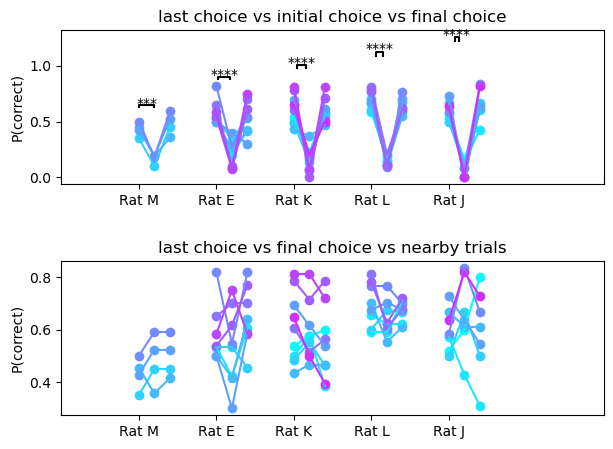

In [26]:
animals = list(correct_wouldhave.keys())
fig,axes = plt.subplots(2,1,figsize = (7,5))
plt.subplots_adjust(wspace=0.8, hspace=0.5)

figure1_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
output_folder = '/stelmo/shijie/change_of_mind_analysis/suppfigure3'

animal_ind = 0
animals = ["Molly","Eliot","Klein","Lewis1","Julio"]
for animal in animals:
    
    ### load data
    file_path = f"{output_folder}/{animal}_correctness.pickle"

    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    correct = data["correct"]
    correct_last = data["correct_last"]
    correct_rand = data["correct_rand"]
    correct_wouldhave = data["correct_wouldhave"]
    dates_to_plot = list(correct.keys())

    norm = Normalize(vmin=0, vmax=len(pre)-1)

    rates = []
    rates_wouldhave = []
    rates_rand = []
    rates_last = []
    for d_ind in range(len(dates_to_plot)):
        d = dates_to_plot[d_ind]
        correct_day = correct[d]
        correct_last_day = correct_last[d]
        correct_wouldhave_day = correct_wouldhave[d]
        correct_rand_day = correct_rand[d]
        
        if len(correct_day) <= 10:
            continue
    
        # rate
        rate = np.sum(correct_day)/len(correct_day)
        rate_last = np.sum(correct_last_day)/len(correct_last_day)
        rate_wouldhave = np.sum(correct_wouldhave_day)/len(correct_wouldhave_day)
        rate_rand = np.sum(correct_rand_day)/len(correct_rand_day) 
        
        rates.append(rate)
        rates_last.append(rate_last)
        rates_wouldhave.append(rate_wouldhave)
        rates_rand.append(rate_rand)

        axe = axes[0]
        axe.scatter(np.zeros_like(rate_last) + animal_ind, rate_last, color = cmap(norm(d_ind)))
        axe.scatter(np.zeros_like(rate_wouldhave) + animal_ind + 0.2, rate_wouldhave, color = cmap(norm(d_ind)))
        axe.scatter(np.zeros_like(rate) + animal_ind + 0.4, rate, color = cmap(norm(d_ind)))
        axe.plot(np.array([0,0.2]) + animal_ind,[rate_last, rate_wouldhave],color = cmap(norm(d_ind)))
        axe.plot(np.array([0.2,0.4]) + animal_ind,[rate_wouldhave, rate],color = cmap(norm(d_ind)))

        axe = axes[1]
        axe.scatter(np.zeros_like(rate_last) + animal_ind, rate_last, color = cmap(norm(d_ind)))
        axe.scatter(np.zeros_like(rate) + animal_ind + 0.2, rate, color = cmap(norm(d_ind)))
        axe.scatter(np.zeros_like(rate_rand) + animal_ind + 0.4, rate_rand, color = cmap(norm(d_ind)))
        
        axe.plot(np.array([0,0.2]) + animal_ind,[rate_last, rate],color = cmap(norm(d_ind)))
        axe.plot(np.array([0.2,0.4]) + animal_ind,[rate, rate_rand],color = cmap(norm(d_ind)))
        

    #### add stats
    t_statistic, p_value = stats.ttest_rel(rate_last, rates_wouldhave)
    print("p_value", p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.2, np.round(p_value, 4))],ax = axes[0])

    t_statistic, p_value = stats.ttest_rel(rate_last, rate)
    print("p_value", p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.2, np.round(p_value, 4))],ax = axes[1])
    ########

    animal_ind += 1


axes[0].set_xticks(np.arange(len(animals)));
axes[0].set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes[0].set_xlim([-1,len(animals) + 1]);
axes[0].set_title("last choice vs initial choice vs final choice")
axes[0].set_ylabel("P(correct)")

axes[1].set_xticks(np.arange(len(animals)));
axes[1].set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes[1].set_xlim([-1,len(animals) + 1]);
axes[1].set_title("last choice vs final choice vs nearby trials")
axes[1].set_ylabel("P(correct)")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/suppfigure3/correcting"
plt.savefig(file_path + ".pdf")
plt.savefig(file_path + ".png")    

### End here